In [ ]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import umap
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
# pip install umap-learn

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 14.5 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---- ----------------------------------- 4.2/38.1 MB 21.0 MB/s eta 0:00:02
   -------- ------------------------------- 7.9/38.1 MB 20.3 MB/s eta 0:00:02
   ------------- -------------------------- 12.6/38.1 MB 19.7 MB/s eta 0:00:02
   ----------------- ---------------------- 17.0/38.1 MB 19.9 MB/s eta 0:00:02
   ---------------------- ----------------- 21.2/38.1 MB 19.7 MB/s eta 0:00:01
   -------------------------- ------------- 25.4/38.1 MB 19.9 MB/s eta 0:00:01
   ------------------------------ --------- 29.4/38.1 MB 19.6 MB/s eta 0:00:01
   --------------------------------- ------ 32.0/38.1 MB 19.0 MB/s eta 0:00:01
   ------------------------------------ --- 35.1/38.1 MB 18.4 MB/s eta 0:00:01
   ---------------------------------------  38.0/38.1 MB 18.2 MB/s eta 0:00:01

In [2]:
df= pd.read_csv("student_productivity_distraction_dataset_20000.csv")

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  str    
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  focus_score  

In [5]:
def show_fig():
    plt.tight_layout()
    plt.show()

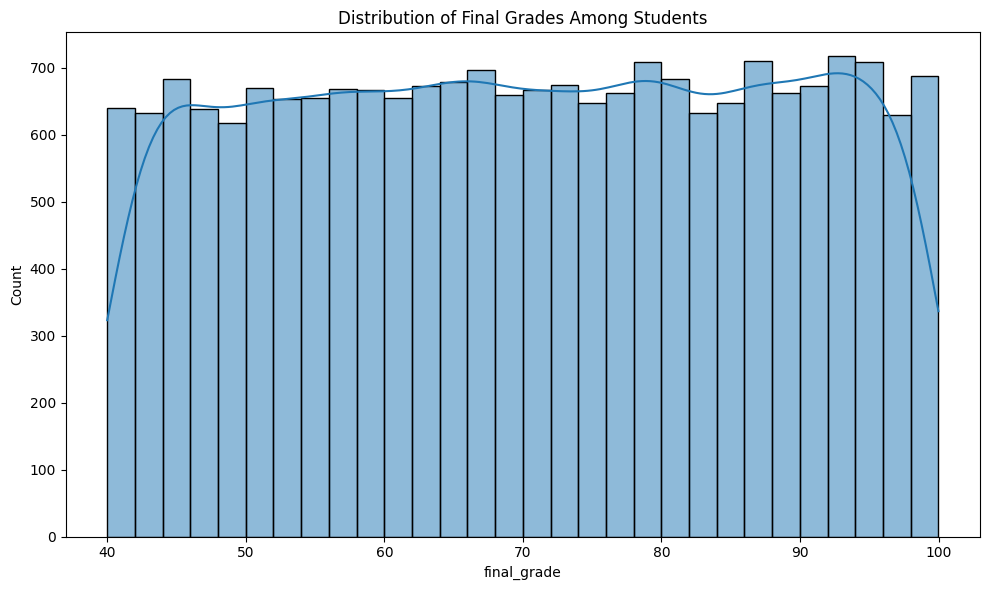

In [6]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['final_grade'], kde=True, bins=30)
plt.title('Distribution of Final Grades Among Students')
show_fig()

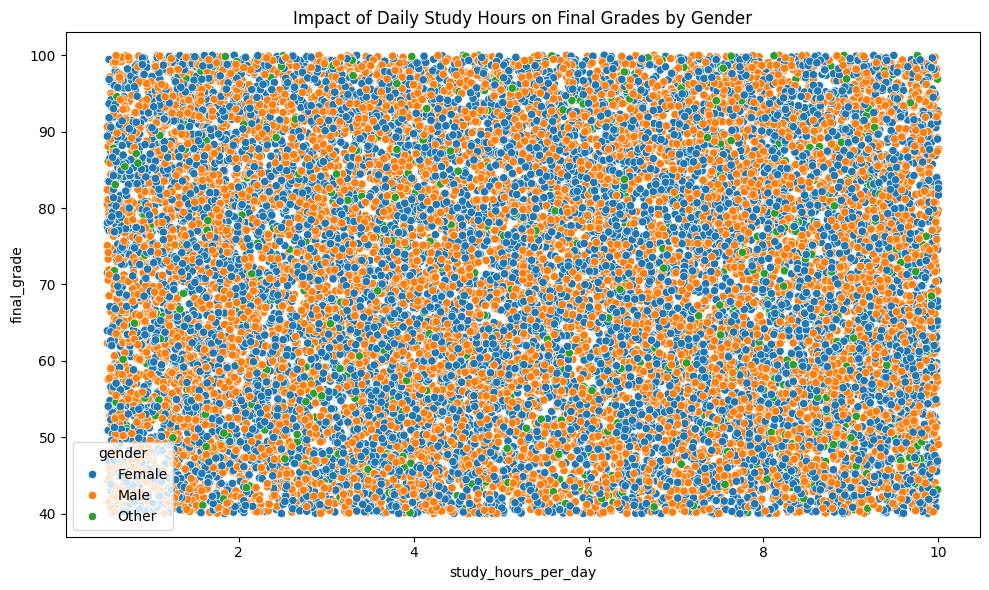

In [7]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='study_hours_per_day', y='final_grade', hue='gender')
plt.title('Impact of Daily Study Hours on Final Grades by Gender')
show_fig()

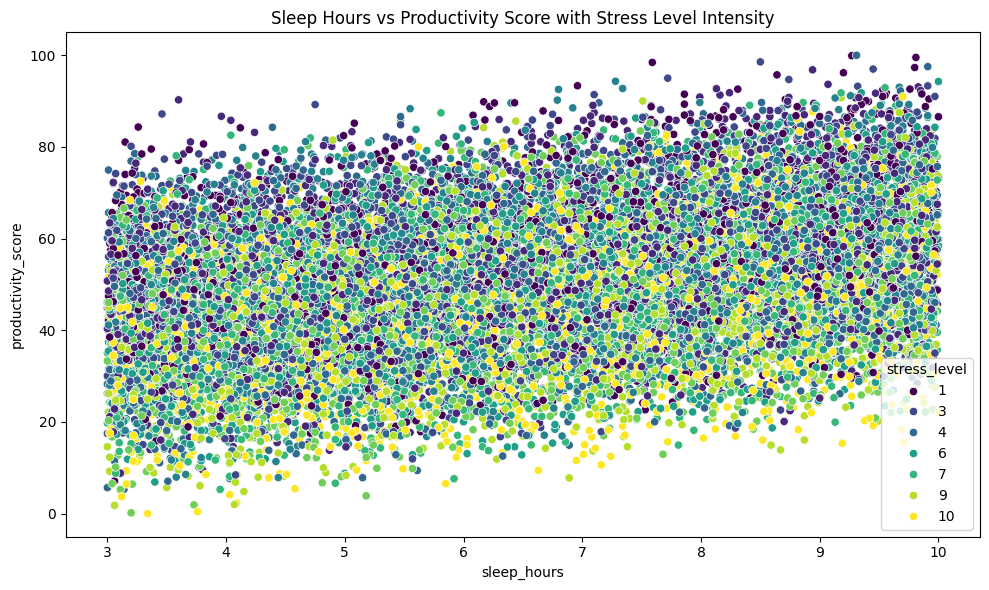

In [8]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='sleep_hours', y='productivity_score', hue='stress_level', palette='viridis')
plt.title('Sleep Hours vs Productivity Score with Stress Level Intensity')
show_fig()

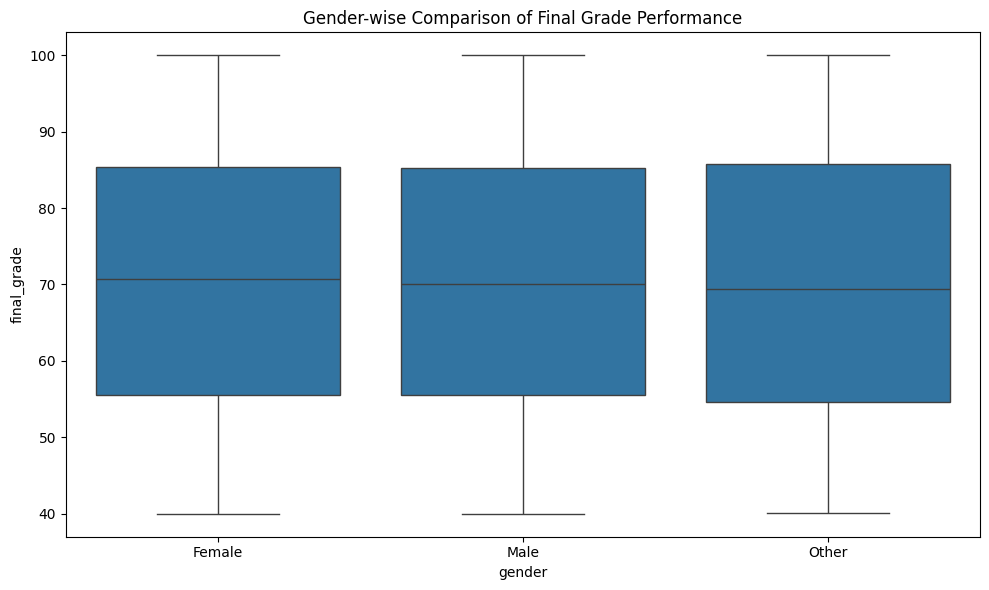

In [9]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y='final_grade')
plt.title('Gender-wise Comparison of Final Grade Performance')
show_fig()

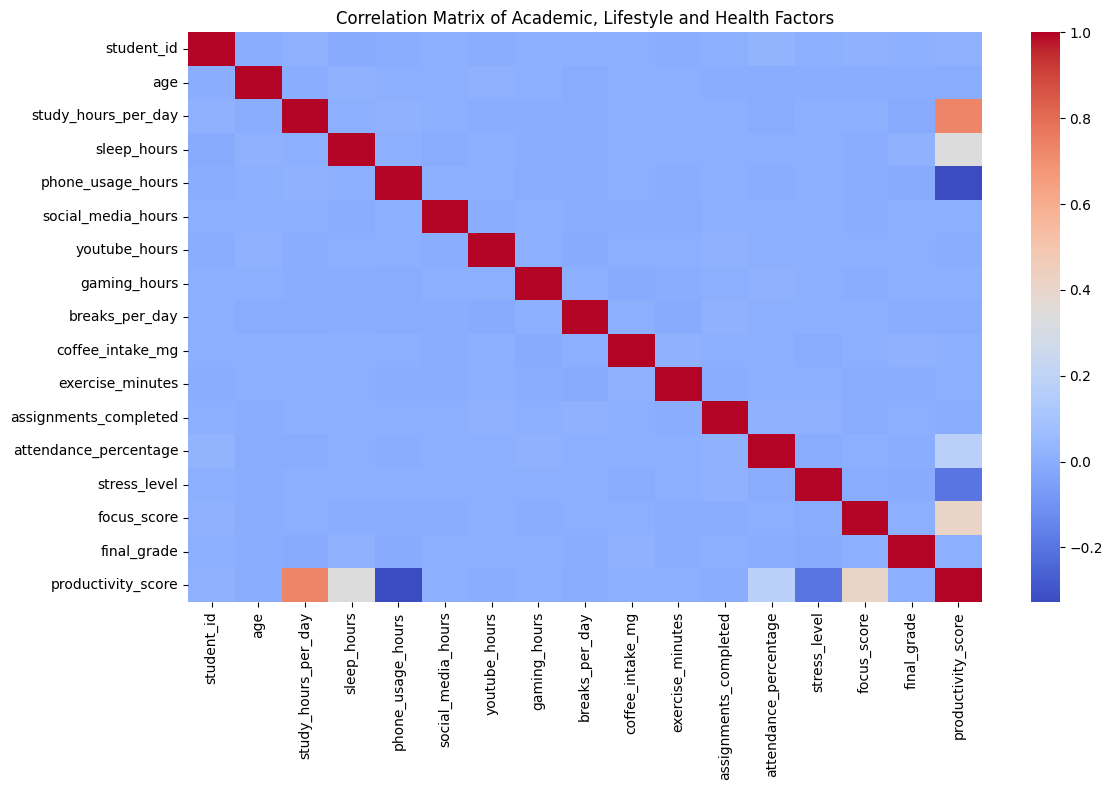

In [10]:
fig = plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Academic, Lifestyle and Health Factors')
show_fig()

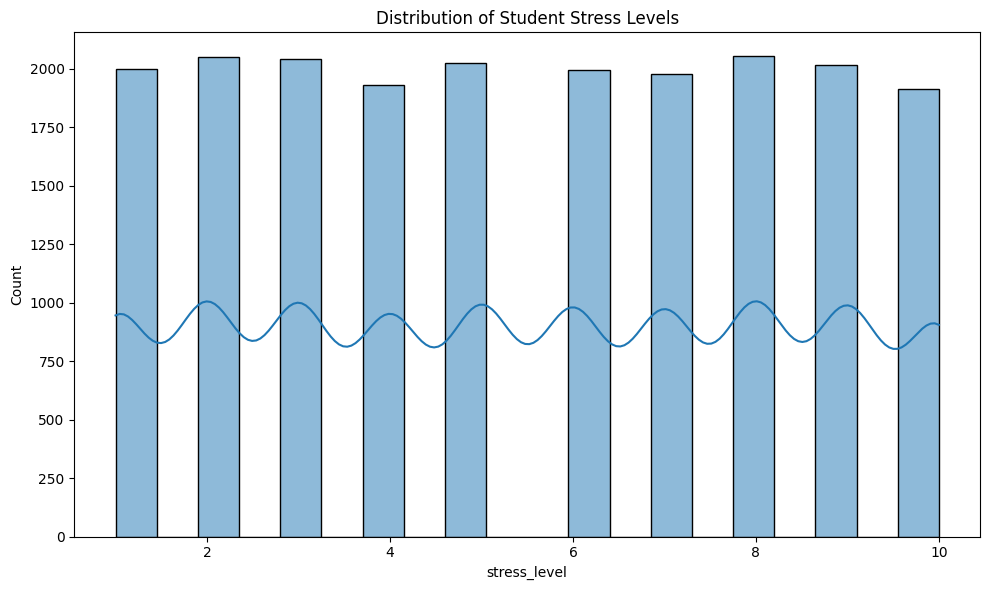

In [11]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['stress_level'], kde=True, bins=20)
plt.title('Distribution of Student Stress Levels')
show_fig()

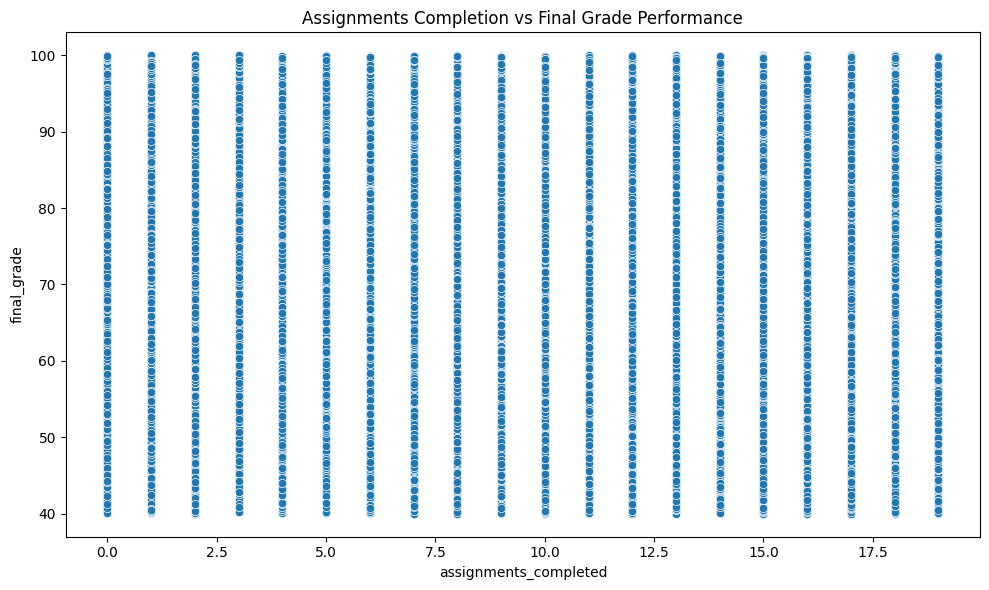

In [12]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='assignments_completed', y='final_grade')
plt.title('Assignments Completion vs Final Grade Performance')
show_fig()

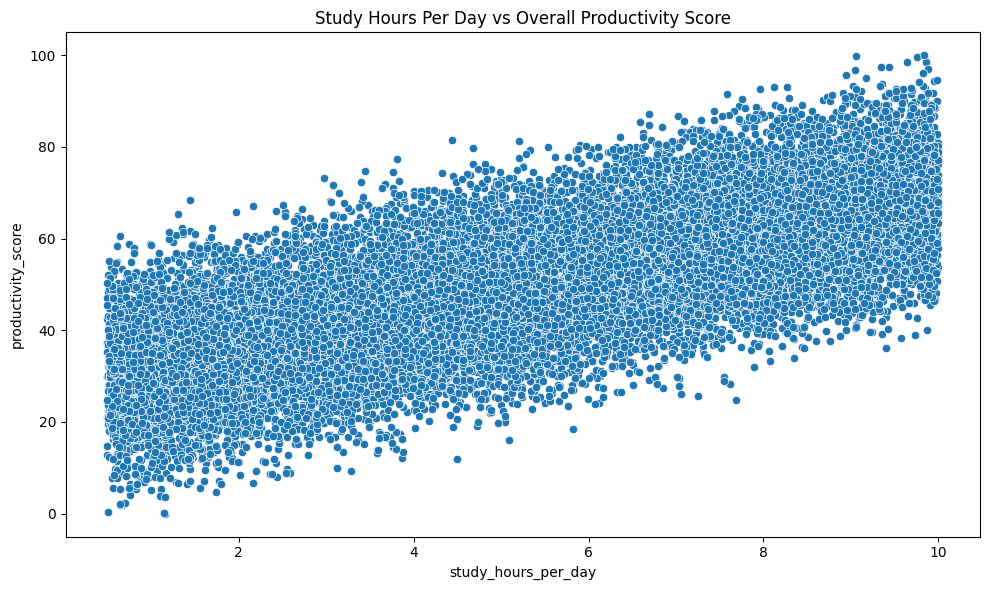

In [13]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='study_hours_per_day', y='productivity_score')
plt.title('Study Hours Per Day vs Overall Productivity Score')
show_fig()

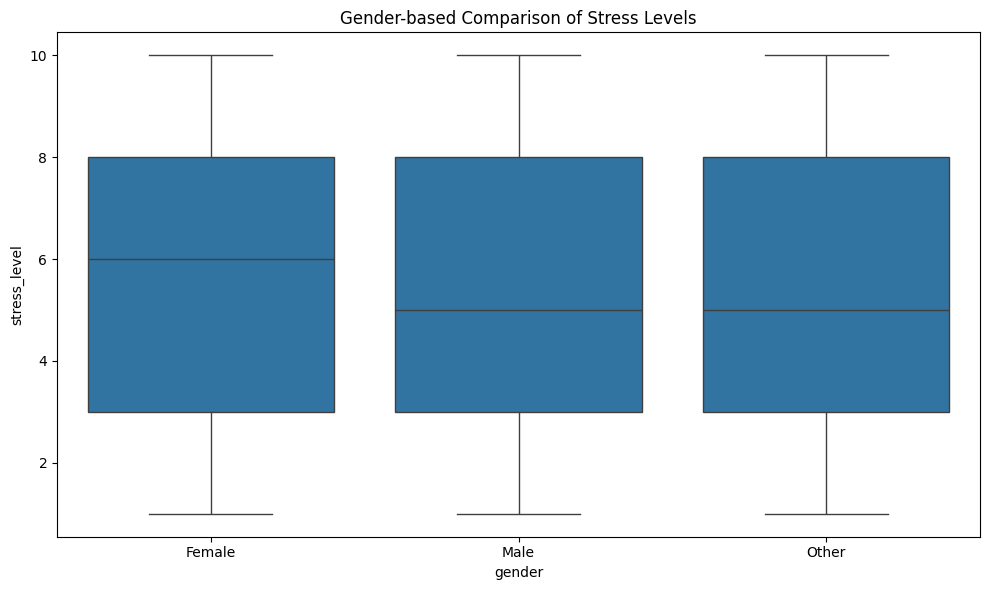

In [14]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='gender', y='stress_level')
plt.title('Gender-based Comparison of Stress Levels')
show_fig()

# model training

In [15]:
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

In [16]:
df = df.dropna()

In [17]:
threshold = df['productivity_score'].quantile(0.25)  # bottom 25% = at-risk
df['risk_label'] = (df['productivity_score'] <= threshold).astype(int)
y = df['risk_label']
y.value_counts()

risk_label
0    14415
1     4807
Name: count, dtype: int64

In [18]:
X = df.drop(columns=[
    'student_id',
    'productivity_score',
    'risk_label'])

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [42]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [43]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3604
           1       0.89      0.93      0.91      1202

    accuracy                           0.95      4806
   macro avg       0.93      0.95      0.94      4806
weighted avg       0.96      0.95      0.95      4806

[[3467  137]
 [  83 1119]]


In [19]:
X.isnull().sum()

age                      0
gender                   0
study_hours_per_day      0
sleep_hours              0
phone_usage_hours        0
social_media_hours       0
youtube_hours            0
gaming_hours             0
breaks_per_day           0
coffee_intake_mg         0
exercise_minutes         0
assignments_completed    0
attendance_percentage    0
stress_level             0
focus_score              0
final_grade              0
dtype: int64

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

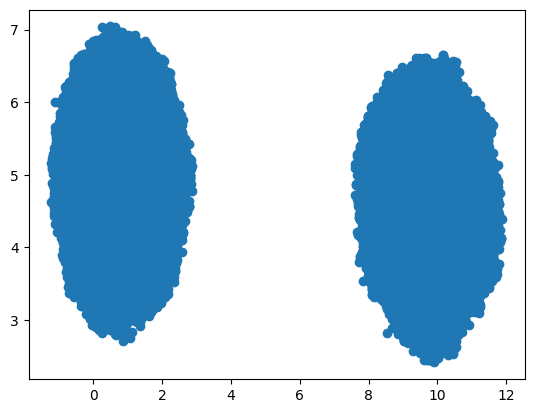

In [56]:
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X_scaled)
plt.scatter(embedding[:,0], embedding[:,1])
plt.show()

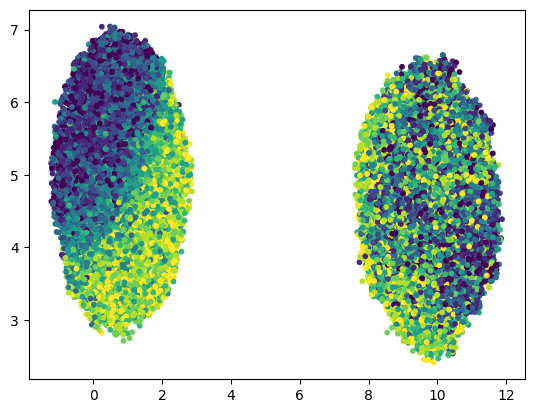

In [57]:
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    c=df['stress_level'],
    cmap='viridis',
    s=10
)

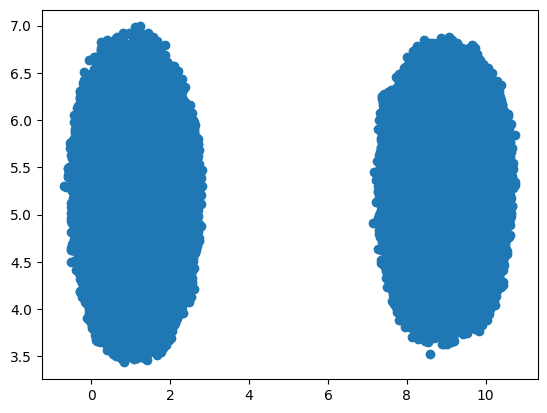

In [51]:
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.01,
    random_state=42
)
embedding = reducer.fit_transform(X_scaled)
plt.scatter(embedding[:,0], embedding[:,1])
plt.show()

In [58]:
from sklearn.manifold import trustworthiness

score = trustworthiness(X_scaled, embedding, n_neighbors=10)
print(score)

0.7246725552018721


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(embedding)

silhouette_score(embedding, clusters)

In [60]:
(embedding[:,0] < 5).sum(), (embedding[:,0] > 5).sum()

(np.int64(9581), np.int64(9641))

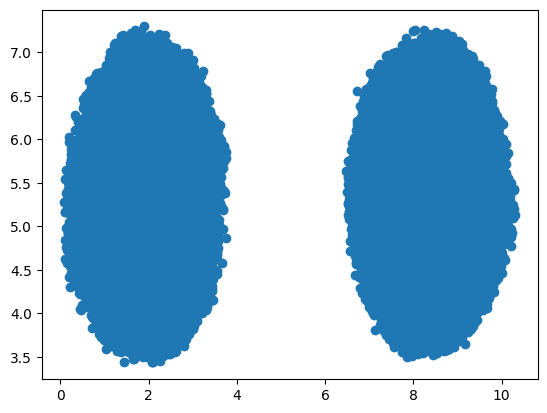

In [61]:
reducer2 = umap.UMAP(
    n_neighbors=50,
    min_dist=0.1,
    random_state=42
)
embedding2 = reducer2.fit_transform(X_scaled)
plt.scatter(embedding2[:,0], embedding2[:,1])
plt.show()

In [62]:
df['cluster'] = clusters
df.groupby('cluster').mean()

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score,risk_label
cluster,,,,,,,,,,,,,,,,,,,
0,10048.856861,23.006327,0.999896,5.243195,6.506377,6.272166,4.003981,2.990274,2.983671,7.513432,249.884348,59.592988,9.484701,70.040232,5.500259,64.578052,70.368550,50.100528,0.24790
1,9952.445987,22.982570,0.000000,5.261770,6.540799,6.232552,4.011550,2.986768,2.989398,7.568104,248.779668,59.743868,9.503914,69.889279,5.454545,64.283791,70.179604,50.267327,0.25227


In [63]:
(df.groupby('cluster').mean().diff().iloc[-1]).abs().sort_values(ascending=False)

student_id               96.410874
coffee_intake_mg          1.104680
gender                    0.999896
focus_score               0.294261
final_grade               0.188946
productivity_score        0.166799
attendance_percentage     0.150954
exercise_minutes          0.150880
breaks_per_day            0.054671
stress_level              0.045714
phone_usage_hours         0.039614
sleep_hours               0.034423
age                       0.023757
assignments_completed     0.019213
study_hours_per_day       0.018575
social_media_hours        0.007569
gaming_hours              0.005727
risk_label                0.004371
youtube_hours             0.003506
Name: 1, dtype: float64

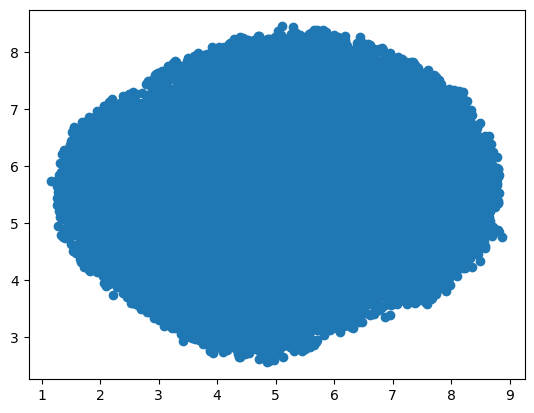

In [21]:
X_behavior = df.drop(columns=['student_id','gender', 'risk_label'])
scaler = StandardScaler()
X_behavior_scaled = scaler.fit_transform(X_behavior)
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)
X_umap_behavior = umap_model.fit_transform(X_behavior_scaled)
plt.scatter(X_umap_behavior[:,0], X_umap_behavior[:,1])
plt.show() 

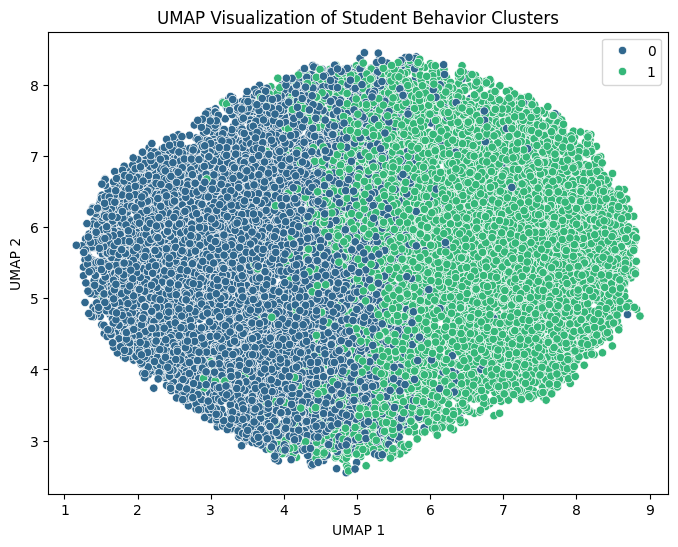

In [24]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_behavior_scaled)
df['cluster'] = clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_umap_behavior[:,0],
    y=X_umap_behavior[:,1],
    hue=clusters,
    palette="viridis"
)

plt.title("UMAP Visualization of Student Behavior Clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.show()

In [25]:
df.groupby('cluster')[X_behavior.columns].mean()

,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
cluster,,,,,,,,,,,,,,,,
0,22.961086,7.185365,6.956749,5.611946,4.021941,2.989991,2.999956,7.533237,250.011974,59.943642,9.513832,71.936034,5.130780,69.674855,70.328471,63.122875
1,23.028425,3.288320,6.083323,6.903241,3.993338,2.987038,2.972878,7.548248,248.644535,59.388295,9.474407,67.962110,5.829767,59.103210,70.219399,37.035456


In [26]:
(df.groupby('cluster').mean().diff().iloc[-1]).abs().sort_values(ascending=False)

student_id               146.222736
productivity_score        26.087418
focus_score               10.571646
attendance_percentage      3.973924
study_hours_per_day        3.897046
coffee_intake_mg           1.367438
phone_usage_hours          1.291295
sleep_hours                0.873426
stress_level               0.698987
exercise_minutes           0.555347
risk_label                 0.504196
final_grade                0.109072
age                        0.067339
assignments_completed      0.039424
social_media_hours         0.028603
gaming_hours               0.027077
breaks_per_day             0.015011
youtube_hours              0.002953
gender                     0.000544
Name: 1, dtype: float64

In [27]:
silhouette_score(X_umap_behavior, clusters)

0.36445632576942444